In [7]:
import pandas as pd
import numpy as np
source = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
tmp = pd.read_html(source, match="Коефіцієнт народжуваності в регіонах України",attrs = {'class':'wikitable collapsible collapsed'},thousands= ".",decimal = ",")
df = tmp[0]
print(df.head())

             Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0              Крим  23.0  20.6  16.0  13.0   7.3  12.6     —     —
1         Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2         Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3  Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4          Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2     —


In [8]:
print(df.shape)

(28, 9)


In [9]:
df.replace('—',np.nan,inplace=True)

In [10]:
print(df.dtypes)


Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014       object
2019       object
dtype: object


In [11]:
for col in df.columns[1:]:
  df[col] = pd.to_numeric(df[col])
print(df.dtypes)


Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object


In [12]:
print(df)

               Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0                Крим  23.0  20.6  16.0  13.0   7.3  12.6   NaN   NaN
1           Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2           Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3    Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   NaN
5         Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
7          Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
9            Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
10     Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   NaN
12          Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
13       Миколаївськ

In [13]:
missing_count = df.isnull().sum()
print(missing_count)

Регіон    0
1950      2
1960      1
1970      1
1990      0
2000      0
2012      0
2014      2
2019      4
dtype: int64


In [14]:
df = df.iloc[:-1]
print(df)

               Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0                Крим  23.0  20.6  16.0  13.0   7.3  12.6   NaN   NaN
1           Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2           Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3    Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   NaN
5         Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
7          Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
9            Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
10     Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   NaN
12          Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
13       Миколаївськ

In [15]:
df = df.fillna(df.mean(numeric_only=True))
print(df)

               Регіон    1950       1960  1970  1990  2000  2012    2014  \
0                Крим  23.000  20.600000  16.0  13.0   7.3  12.6  11.144   
1           Вінницька  22.400  19.200000  14.2  12.4   8.4  11.2  10.900   
2           Волинська  24.700  25.000000  17.9  15.3  11.2  14.8  14.100   
3    Дніпропетровська  20.400  20.400000  15.1  12.3   7.1  11.2  11.100   
4            Донецька  27.100  21.400000  14.0  10.9   6.1   9.8   8.200   
5         Житомирська  26.100  22.300000  15.9  12.9   8.9  12.2  12.000   
6        Закарпатська  31.400  27.300000  20.7  16.8  11.5  15.1  14.600   
7          Запорізька  21.900  19.700000  15.0  12.4   7.1  10.6  10.600   
8   Івано-Франківська  24.300  24.800000  18.2  15.5  10.3  12.4  12.200   
9            Київська  20.400  18.900000  15.6  12.3   7.3  12.2  12.100   
10     Кіровоградська  21.600  17.100000  14.5  12.6   7.9  11.0  10.800   
11          Луганська  26.200  23.500000  14.4  11.6   6.2   9.6   5.100   
12          

In [16]:
avg_2019 = df['2019'].mean()
high_for_avg = df[df['2019']>avg_2019]
list_regions = high_for_avg['Регіон'].tolist()
print(list_regions)

['Волинська', 'Закарпатська', 'Івано-Франківська', 'Львівська', 'Одеська', 'Рівненська', 'Херсонська', 'Чернівецька', 'Київ']


In [17]:
max_2014 = df['2014'].max()
max_region = df[df['2014'] == max_2014]['Регіон']
print(max_region)

16    Рівненська
Name: Регіон, dtype: object


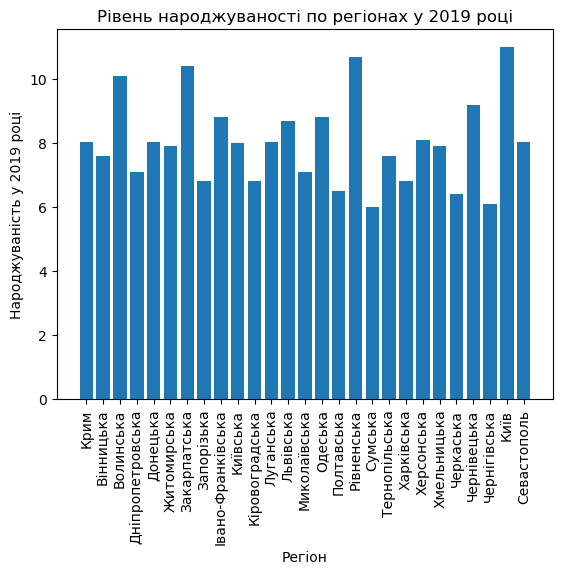

In [62]:
import matplotlib.pyplot as plt
plt.bar(df['Регіон'], df['2019'])
plt.xticks(rotation=90)  
plt.xlabel('Регіон')
plt.ylabel('Народжуваність у 2019 році')
plt.title('Рівень народжуваності по регіонах у 2019 році')
plt.show()

Text(0, 0.5, 'Коефіцієнт народжуваності')

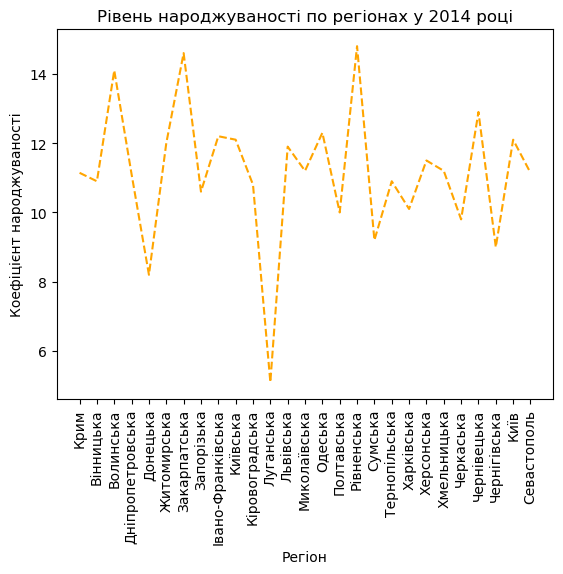

In [65]:
plt.plot(df['Регіон'], df['2014'],color = 'orange',linestyle = 'dashed')
plt.xticks(rotation=90) 
plt.title('Рівень народжуваності по регіонах у 2014 році')
plt.xlabel("Регіон")
plt.ylabel("Коефіцієнт народжуваності")

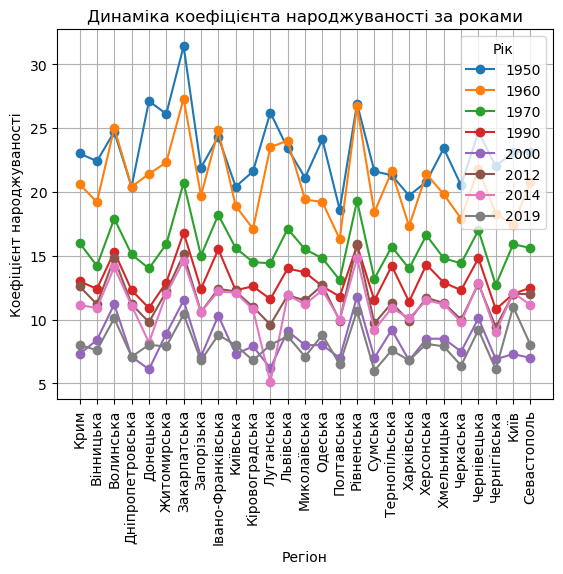

In [66]:
years = df.columns[1:] 

for year in years:
    plt.plot(df['Регіон'], df[year], marker='o', label=year) 

plt.xticks(rotation=90) 
plt.xlabel("Регіон")
plt.ylabel("Коефіцієнт народжуваності")
plt.title("Динаміка коефіцієнта народжуваності за роками")
plt.legend(title="Рік")
plt.grid(True)
plt.show()